In [1]:
import os
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn2

os.chdir('/Users/stacyli/savio/global/scratch/stacy-l/spermSV')
sns.set_style('white')

# hg38 benchmark results (SV Tier 1 v0.6)
Process summary:
1) Subsample `HG002` winnowmap `*bam` to 1X, `samtools merge` with `894` winnowmap `*.bam`.
2) Run `sniffles mosaic` on merged simulation bam.
3) Use `liftoverVcf` from `picard` to convert GIAB SV Tier 1 callset from `GrCh37` (`hg19`) to `GrCh38` (`hg38`). 
    * Logfile on conversion is available in `benchmarks/HG002/liftoverVcf/hg38`.
4) Use `bcftools filter` to create subset `*.vcf.gz` files of the liftover callset.
5) Use `bcftools filter` to create subset `*.vcf.gz` files of the simulation callset.
4) Run `truvari bench` with `--pass-only` to assess overlap between simulation calls and SV Tier 1 calls, where both have `FILTER == PASS`.

> "The Tier 1 benchmark regions, for which any extra calls are putative false positives, cover 2.51 Gbp and 5262 insertions and 4095 deletions (note: 9357 total variants) supported by ≥1 diploid assembly."

In [2]:
# truvari parameters (output collapsed) – insertion benchmark as example
pd.read_json('output/mapping/hg38_old/simulations/merge_mapped/filtered/filter_01/truvari/ins/params.json', typ = 'series').to_dict()

{'base': '/global/scratch/users/stacy-l/spermSV/output/mapping/hg38_old/simulations/merge_mapped/filtered/filter_01/SVTier1_ins_max10kb.vcf.gz',
 'comp': '/global/scratch/users/stacy-l/spermSV/output/mapping/hg38_old/simulations/merge_mapped/filtered/filter_01/HG002_894_simulation_ins.vcf.gz',
 'output': 'output/mapping/hg38_old/simulations/merge_mapped/filtered/filter_01/truvari/ins',
 'includebed': None,
 'extend': 0,
 'debug': False,
 'reference': None,
 'refdist': 500,
 'pctseq': 0.7000000000000001,
 'minhaplen': 50,
 'pctsize': 0.7000000000000001,
 'pctovl': 0.0,
 'typeignore': False,
 'chunksize': 1000,
 'bSample': 'HG002',
 'cSample': 'SAMPLE',
 'dup_to_ins': False,
 'sizemin': 50,
 'sizefilt': 30,
 'sizemax': 50000,
 'passonly': True,
 'no_ref': False,
 'pick': 'single',
 'check_monref': True,
 'check_multi': True}

# Simulation output filters

| Filter | SV length | Support reads | SV types |
|--------|-----------|---------------|----------|
| 01     | < 10 kb   | == 1          | INS, DEL |
| 02     | < 10 kb   | == 2          | INS, DEL |
| 03     | < 10 kb   | <= 2          | INS, DEL |
| 04     | < 10 kb   | == 3          | INS, DEL |
| 05     | < 2 kb    | == 1          | INS, DEL |
| 06     | < 1 kb    | == 1          | INS, DEL |

tl;dr: At 1X, SVs supported by a greater number of reads are actually *less* likely to match with benchmark set variants. SV length doesn't appear to play a role at all under the 10kb mark.

In [3]:
# reading in the data from truvari json report
filter_01_ins = pd.read_json('output/mapping/hg38_old/simulations/merge_mapped/filtered/filter_01/truvari/ins/summary.json')
filter_01_del = pd.read_json('output/mapping/hg38_old/simulations/merge_mapped/filtered/filter_01/truvari/del/summary.json')
filter_02_ins = pd.read_json('output/mapping/hg38_old/simulations/merge_mapped/filtered/filter_02/truvari/ins/summary.json')
filter_02_del = pd.read_json('output/mapping/hg38_old/simulations/merge_mapped/filtered/filter_02/truvari/del/summary.json')
filter_03_ins = pd.read_json('output/mapping/hg38_old/simulations/merge_mapped/filtered/filter_03/truvari/ins/summary.json')
filter_03_del = pd.read_json('output/mapping/hg38_old/simulations/merge_mapped/filtered/filter_03/truvari/del/summary.json')
filter_04_ins = pd.read_json('output/mapping/hg38_old/simulations/merge_mapped/filtered/filter_04/truvari/ins/summary.json')
filter_04_del = pd.read_json('output/mapping/hg38_old/simulations/merge_mapped/filtered/filter_04/truvari/del/summary.json')
filter_05_ins = pd.read_json('output/mapping/hg38_old/simulations/merge_mapped/filtered/filter_05/truvari/ins/summary.json')
filter_05_del = pd.read_json('output/mapping/hg38_old/simulations/merge_mapped/filtered/filter_05/truvari/del/summary.json')
filter_06_ins = pd.read_json('output/mapping/hg38_old/simulations/merge_mapped/filtered/filter_06/truvari/ins/summary.json')
filter_06_del = pd.read_json('output/mapping/hg38_old/simulations/merge_mapped/filtered/filter_06/truvari/del/summary.json')

In [4]:
insertions = pd.concat([filter_01_ins, filter_02_ins, filter_03_ins, filter_04_ins, filter_05_ins, filter_06_ins]).loc['size'].reset_index(drop = True)
insertions['filter'] = np.arange(1,7)
insertions['type'] = 'Insertions'
deletions = pd.concat([filter_01_del, filter_02_del, filter_03_del, filter_04_del, filter_05_del, filter_06_del]).loc['size'].reset_index(drop = True)
deletions['filter'] = np.arange(1,7)
deletions['type'] = 'Deletions'
truvari = pd.concat([insertions, deletions]).reset_index(drop = True)

/var/folders/d1/_d4s2fqs7_z4dhbkbh6b02xw0000gn/T/ipykernel_13045/241734475.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=ax[0,0], data=insertions.loc[[0, 1, 3]], x = 'filter', y = 'precision', edgecolor = 'white', label = 'Precision (insertions)',
/var/folders/d1/_d4s2fqs7_z4dhbkbh6b02xw0000gn/T/ipykernel_13045/241734475.py:3: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.barplot(ax=ax[0,0], data=insertions.loc[[0, 1, 3]], x = 'filter', y = 'precision', edgecolor = 'white', label = 'Precision (insertions)',
/var/folders/d1/_d4s2fqs7_z4dhbkbh6b02xw0000gn/T/ipykernel_13045/241734475.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.bar

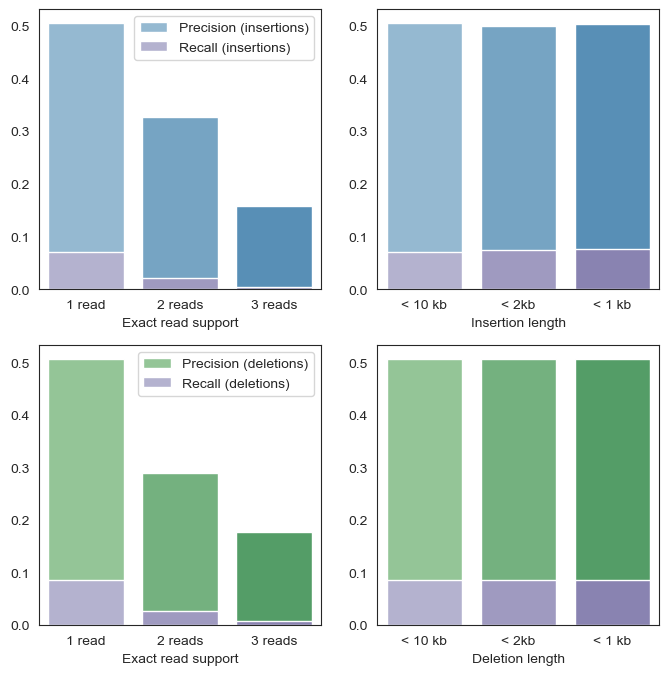

In [35]:
fig, ax = plt.subplots(ncols = 2, nrows = 2, figsize = (8, 8))

sns.barplot(ax=ax[0,0], data=insertions.loc[[0, 1, 3]], x = 'filter', y = 'precision', edgecolor = 'white', label = 'Precision (insertions)',
            palette = sns.color_palette("Blues_d"))
sns.barplot(ax=ax[0,0], data=insertions.loc[[0, 1, 3]], x = 'filter', y = 'recall', edgecolor = 'white', label = 'Recall (insertions)',
            palette = sns.color_palette("Purples_d"))
sns.barplot(ax=ax[0,1], data=insertions.loc[[0, 4, 5]], x = 'filter', y = 'precision', edgecolor = 'white', label = 'Precision (insertions)',
            palette = sns.color_palette("Blues_d"))
sns.barplot(ax=ax[0,1], data=insertions.loc[[0, 4, 5]], x = 'filter', y = 'recall', edgecolor = 'white', label = "Recall (insertions)",
            palette = sns.color_palette("Purples_d"))
ax[0,0].set_xlabel('Exact read support')
ax[0,0].set_ylabel('')
ax[0,0].set_xticks(ticks = ax[0,0].get_xticks(), labels = ['1 read', '2 reads', '3 reads'])
ax[0,0].legend(handles = [ax[0,0].get_legend_handles_labels()[0][0], ax[0,0].get_legend_handles_labels()[0][3]])
ax[0,1].set_xlabel('Insertion length')
ax[0,1].set_ylabel('')
ax[0,1].set_xticks(ticks = ax[0,1].get_xticks(), labels = ['< 10 kb', '< 2kb', '< 1 kb'])

sns.barplot(ax=ax[1,0], data=deletions.loc[[0, 1, 3]], x = 'filter', y = 'precision', edgecolor = 'white', label = 'Precision (deletions)',
            palette = sns.color_palette("Greens_d"))
sns.barplot(ax=ax[1,0], data=deletions.loc[[0, 1, 3]], x = 'filter', y = 'recall', edgecolor = 'white', label = 'Recall (deletions)',
            palette = sns.color_palette("Purples_d"))
sns.barplot(ax=ax[1,1], data=deletions.loc[[0, 4, 5]], x = 'filter', y = 'precision', edgecolor = 'white', label = 'Precision (deletions)',
            palette = sns.color_palette("Greens_d"))
sns.barplot(ax=ax[1,1], data=deletions.loc[[0, 4, 5]], x = 'filter', y = 'recall', edgecolor = 'white', label = 'Recall (deletions)',
            palette = sns.color_palette("Purples_d"))
ax[1,0].set_xlabel('Exact read support')
ax[1,0].set_ylabel('')
ax[1,0].set_xticks(ticks = ax[1,0].get_xticks(), labels = ['1 read', '2 reads', '3 reads'])
ax[1,0].legend(handles = [ax[1,0].get_legend_handles_labels()[0][0], ax[1,0].get_legend_handles_labels()[0][3]])
ax[1,1].set_xlabel('Deletion length')
ax[1,1].set_ylabel('')
ax[1,1].set_xticks(ticks = ax[1,1].get_xticks(), labels = ['< 10 kb', '< 2kb', '< 1 kb'])

Text(0.5, 1.0, 'Deletions')

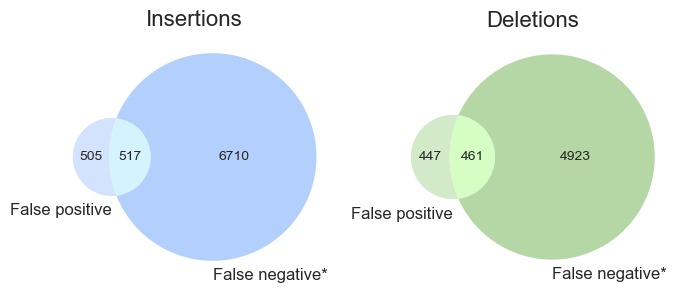

In [36]:
fig, ax = plt.subplots(ncols = 2, figsize = (8, 4))
venn2(ax=ax[0], subsets=(filter_01_ins.iloc[0]['FP'], filter_01_ins.iloc[0]['FN'], filter_01_ins.iloc[0]['TP-comp']), set_labels = ("False positive", "False negative*", "True positive"), set_colors = ['#93bbfa', '#4287f5'])
venn2(ax=ax[1], subsets=(filter_01_del.iloc[0]['FP'], filter_01_del.iloc[0]['FN'], filter_01_del.iloc[0]['TP-comp']), set_labels = ("False positive", "False negative*", "True positive"), set_colors = ['#93cc7a', '#469c21'])

ax[0].set_title("Insertions", size = 16)
ax[1].set_title("Deletions", size = 16)

# Germline benchmark

Text(0.5, 1.0, 'Precision: 47.3%, Recall: 93.3%')

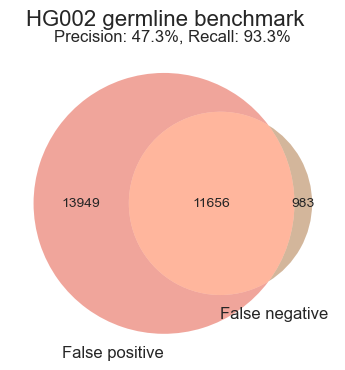

In [38]:
germline = pd.read_json('output/mapping/hg38_old/simulations/merge_mapped/truvari_germline/summary.json')
fig, ax = plt.subplots(figsize = (6, 4))
venn2(subsets=(germline.iloc[0]['FP'], germline.iloc[0]['FN'], germline.iloc[0]['TP-comp']), set_labels = ("False positive", "False negative", "True positive"), set_colors = ['#db1f07', '#914a07'])
plt.suptitle("HG002 germline benchmark", size = 16)
plt.title("Precision: 47.3%, Recall: 93.3%", size = 12)

# To do (copy and edit further on next notebook)
* Precision/recall curves as a function of SV size: germline and simulation
    * x-axis points have to be analyzed as separate runs of truvari: immediate task is to plot existing SV distributions of both germline and simulation
* Convert truvari false negative of simulations to bedfile
    * Identify if any reads from HG002_subsampled bamfile overlap the false negative bedfile: describes more accurately actual false negatives, because the variants without ANY reads on top should never be included as part of the comparison set (improves recall). 
        * Can use `bedtools coverage`
* Improve precision by restricting SV candidates from simulation to those with high confidence flanking sequences around SV breakpoints
    * Maybe this exists somewhere already? If not, go from `sniffles` output: 1) pull ALT sequence (for INS), 2) `RNAMES` -> pull sequence from bamfile, 3) for ins, substring search with str methods: make sure index location is some % flanked on each side on the bread, 4) for del, more complex... check mapping position of start/end of read, compare to breakpoint proposed by sniffles, make sure breakpoint location vs. read map location is some % flanked
* Pop open the false positive file, break down...
    * Chromosome position
    * SV length
    * For insertions: insertion content
* Check if false positives (1 read support) are present in germline calls and contribute to a true call.

Lower tier ideas:
* Use H1/H2 assemblies from `hifiasm` on each sample: generate simulated reads, use as "normal" sample + actual sample as "tumor" sample on matched tumor-normal callers like deepSomatic (and other ones???)
    * Can also test this idea with hg38 + in silico SV reads
* Use H1/H2 assemblies from `hifiasm` and remap reads to their own matched assemblies, rerun pipeline
    * This one is not the lowest tier, we already have these assemblies for each sample – can also test this idea with hg38 + in silico SV reads
* Look at what the hell Cue is doing for somatic SV calling. Is it only short read???